## Supernova distances and redshift
In this excercise we want to analyze the relationship between the magnitude and distance of Type 1a Supernovae. To do so, we will use different regression methods such as linear, polyomial, Kernel and Basis function regression.


In [2]:

import numpy as np
from matplotlib import pyplot as plt

from sklearn.mixture import GaussianMixture
from astroML.resample import jackknife
from astroML.stats import sigmaG
from scipy.stats import chi2
import scipy
#from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize = 10, usetex = True)
from scipy.stats import loguniform
from sklearn import datasets
from sklearn import manifold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


Visualizing the data

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
C:\Users\alexv\AppData\Local\Temp\ipykernel_10832\1031658797.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


(35.0, 50.0)

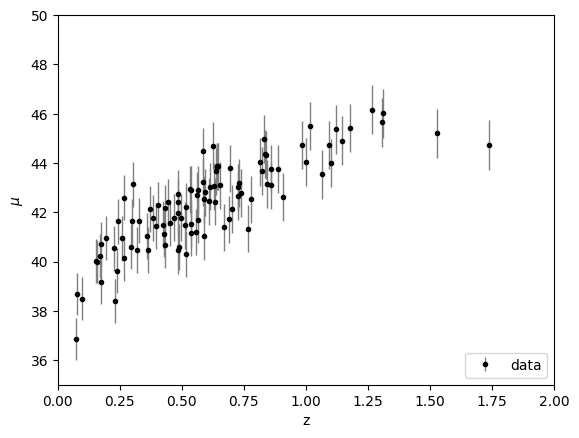

In [3]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel(r"$z$
")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)


In [4]:
z_sample = z_sample[:, np.newaxis]

### Linear regression

In [5]:
from astroML.linear_model import LinearRegression

dytest = dmu # mu errors

model = LinearRegression()
model.fit(z_sample, mu_sample, dmu)

print(model.coef_)


[39.48384602  4.76438865]


C:\Users\alexv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
C:\Users\alexv\AppData\Local\Temp\ipykernel_10832\3455890708.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


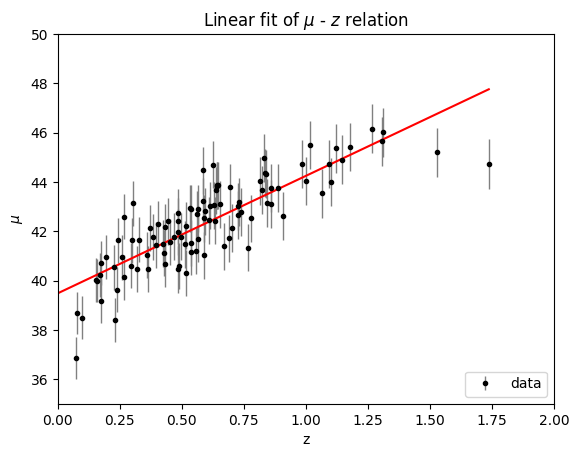

In [6]:
#Plotting linear fit
grid = np.linspace(0, z_sample.max(), 100)
grid_test_lin = grid[:, np.newaxis]
mu_pred = model.predict(grid_test_lin)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel(r"$z$")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)
plt.title(r"Linear fit of $\mu$ - $z$ relation") 
plt.plot(grid_test_lin, mu_pred, color = 'red', linestyle = '-')

### Polynomial Regression

[   35.26610351    32.52717374    84.29772043 -1185.1963162
  4221.82035281 -7581.90261614  7725.37965823 -4516.73127645
  1411.30781044  -182.62797455]


<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
C:\Users\alexv\AppData\Local\Temp\ipykernel_10832\4175954438.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


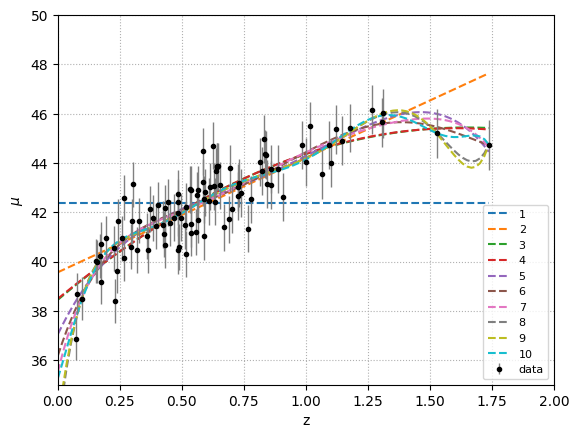

In [7]:
from astroML.linear_model import PolynomialRegression

mu_pred_pol = []
n_constraints = []
grid_test_pol = grid[:, np.newaxis]
#Polynomial fit with increasing degree
for i in range(10):

    model = PolynomialRegression(i) 
    model.fit(z_sample, mu_sample)
    mu_pred_pol.append(model.predict(grid_test_pol))
    n_constraints.append(i + 1)
    
    #Plot each polynomial fit
    plt.plot(grid_test_pol, mu_pred_pol[i], linestyle = '--', label = i+1)
    

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel(r"$z$")
plt.ylabel(r"$\mu$")

plt.title(r"Polynomial regression of $\mu$ - $z$ relation") 
plt.legend(loc='lower right', fontsize = 8)
plt.xlim(0,2)
plt.ylim(35,50)
plt.grid(linestyle = ':')



### Kernel Regression

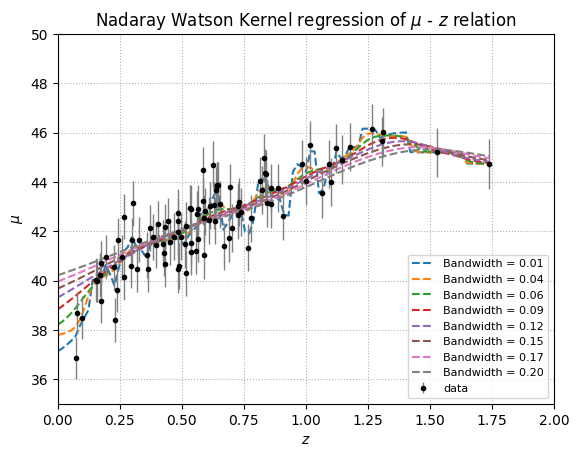

In [16]:
from astroML.linear_model import NadarayaWatson

mu_pred_nw = []
bw = np.linspace(0.01,0.2, 8)
n_constraints = []
grid_test_nw = grid[:, np.newaxis]

#Fit of Kernel regression with increasing bandwidth of the kernel
for i in range(len(bw)):

    model = NadarayaWatson(kernel = 'gaussian', h = bw[i]) 
    model.fit(z_sample, mu_sample)
   
    mu_pred_nw.append(model.predict(grid_test_nw))
    n_constraints.append(i + 1)
    
    plt.plot(grid_test_nw, mu_pred_nw[i], linestyle = '--', label = f"Bandwidth = {bw[i]:.2f}")

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel(r"$z$")
plt.ylabel(r"$\mu$")
plt.title(r"Nadaray Watson Kernel regression of $\mu$ - $z$ relation") 
plt.legend(loc='lower right', fontsize = 8)
plt.xlim(0,2)
plt.ylim(35,50)
plt.grid(linestyle = ':')

### Basis Function

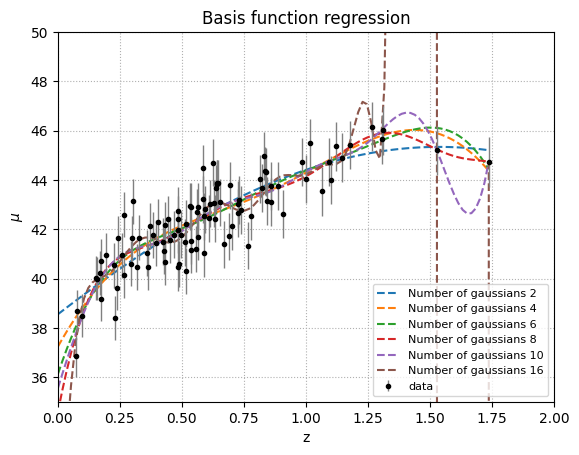

In [17]:
from astroML.linear_model import BasisFunctionRegression

mu_pred_bf = []
grid_test_bf = grid[:, np.newaxis]
n_gauss = [2, 4, 6, 8, 10, 16]

#Basis function fit using an increasing number of gaussians
for i in range(len(n_gauss)):
    #defining mean and width of the gaussians
    basis_mu = np.linspace(0, 2, n_gauss[i])[:, None]
    sigma_basis = 1*(basis_mu[1]-basis_mu[0])
    
    model = BasisFunctionRegression('gaussian', mu=basis_mu, sigma=sigma_basis)
    model.fit(z_sample, mu_sample, dmu)
    mu_pred_bf.append(model.predict(grid_test_bf))

    
    plt.plot(grid_test_bf, mu_pred_bf[i], linestyle = '--', label = f"Number of gaussians {n_gauss[i]}")

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel(r"$z$")
plt.ylabel(r"$\mu$")
plt.title(r"Basis function regression of $\mu$ - $z$ relation") 
plt.legend(loc='lower right', fontsize = 8)
plt.xlim(0,2)
plt.ylim(35,50)
plt.grid(linestyle = ':')

### Cross validation
To optimize the model hyperparameters (such as the bandwidth and the number of Gaussian components), we split the dataset into training and validation subsets. We then evaluate how the prediction error evolves on both subsets. The optimal hyperparameter value corresponds to the minimum root mean square (RMS) error observed on the validation set.
The RMS error is computed as:
$$\epsilon_{\rm cv/tr} = \sqrt{\frac{1}{n}\sum_{i=1}^{N_{\rm cv/tr}}
  \left[y_i - \sum_{m=0}^d \theta_0^{(n)}x_i^m\right]^2}$$
where $\epsilon_{cv}, \epsilon_{tr}$ denote the validation and training errors, respectively.

In [10]:

def get_errors(xtrain, ytrain, dytrain, xval, yval, model):
    model.fit(xtrain, ytrain, dytrain)
    pred_train = model.predict(xtrain)
    pred_val = model.predict(xval)

    err_train = np.sqrt(np.sum((ytrain - pred_train)**2)/len(xtrain))
    err_val = np.sqrt(np.sum((yval - pred_val)**2)/len(xval))

    return err_train, err_val


In [11]:
print(z_sample.shape)
ydy = np.array([mu_sample, dmu]).T    # combine errors and magnitudes in 1 array: [mu_i, dmu_i]

xtrain, xvalid, ydy_train, ydy_validation = train_test_split(
    z_sample, ydy, test_size=0.3, random_state=42
)

# Reconvert ydy in y e dy separately
ytrain, dytrain = ydy_train.T
yvalid, dyvalid = ydy_validation.T
xtrain = xtrain.reshape(-1, 1)
xvalid = xvalid.reshape(-1, 1)
print(xtrain.shape)  # (N_train, 1)
print(xvalid.shape)  #(N_valid, 1)
print(ytrain.shape)  #(N_train,)
print(dytrain.shape)

(100, 1)
(70, 1)
(30, 1)
(70,)
(70,)


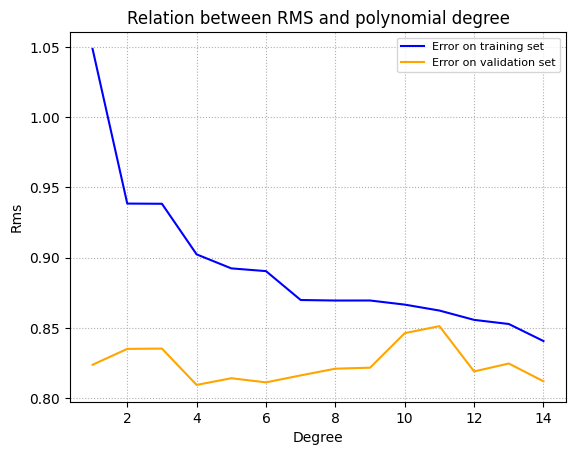

In [18]:
##Cross validation for POLYNOMIAL REGRESSION

n_constraints = []
err_train_arr = []
err_val_arr = []


for i in range(1,15):

    model = PolynomialRegression(i) 
    err_train, err_val = get_errors(xtrain, ytrain, dytrain, xvalid, yvalid, model)

    err_train_arr.append(err_train)
    err_val_arr.append(err_val)
    n_constraints.append(i)
    

plt.plot(n_constraints, err_train_arr, color = 'blue', label = 'Error on training set')
plt.plot(n_constraints, err_val_arr, color = 'orange', label = 'Error on validation set')
plt.title("Relation between RMS and polynomial degree")
plt.xlabel("Degree")
plt.ylabel("Rms")
plt.legend(loc='upper right', fontsize = 8)

plt.grid(linestyle = ':')


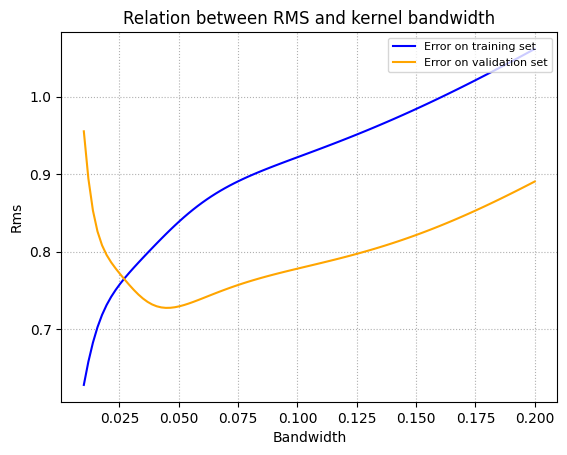

In [20]:
##Cross validation for Nadaray-Watson Regression
bw =  np.linspace(0.01,0.2,100)
err_train_arr_bw = []
err_val_arr_bw = []
for i in range(len(bw)):

    model = NadarayaWatson(kernel = 'gaussian', h = bw[i]) 
    err_train, err_val = get_errors(xtrain, ytrain, dytrain, xvalid, yvalid, model)
  
    err_train_arr_bw.append(err_train)
    err_val_arr_bw.append(err_val)

    

plt.plot(bw, err_train_arr_bw, color = 'blue', label = 'Error on training set')
plt.plot(bw, err_val_arr_bw, color = 'orange', label = 'Error on validation set')
plt.title("Relation between RMS and kernel bandwidth")
plt.xlabel("Bandwidth")
plt.ylabel("Rms")
plt.legend(loc='upper right', fontsize = 8)

plt.grid(linestyle = ':')
    



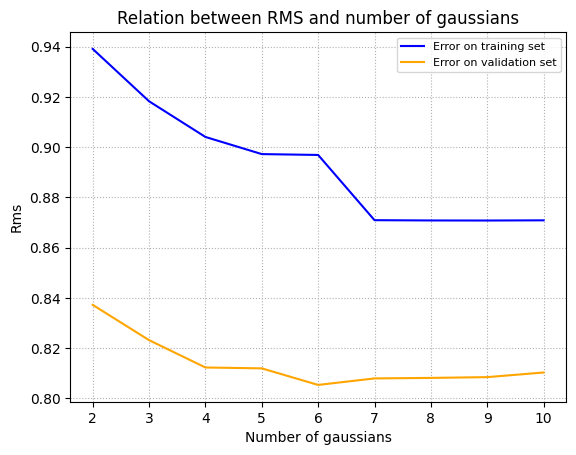

In [21]:
##Cross validation for Basis function Regression
n_gauss = np.arange(2,11)
err_train_arr_bf = []
err_val_arr_bf = []
for i in range(len(n_gauss)):
    basis_mu = np.linspace(0, 2, n_gauss[i])[:, None]
    sigma_basis = 1*(basis_mu[1]-basis_mu[0])
    model = BasisFunctionRegression('gaussian', mu=basis_mu, sigma=sigma_basis)
    
    err_train, err_val = get_errors(xtrain, ytrain, dytrain, xvalid, yvalid, model)
    err_train_arr_bf.append(err_train)
    err_val_arr_bf.append(err_val)

    

plt.plot(n_gauss, err_train_arr_bf, color = 'blue', label = 'Error on training set')
plt.plot(n_gauss, err_val_arr_bf, color = 'orange', label = 'Error on validation set')

plt.xlabel("Number of gaussians")
plt.ylabel("Rms")
plt.legend(loc='upper right', fontsize = 8)
plt.title("Relation between RMS and number of gaussians")
plt.grid(linestyle = ':')
    

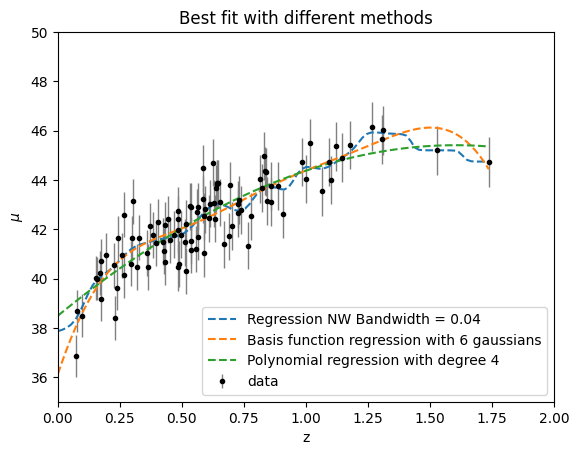

In [15]:
#extracting optimal hyperparameters
idx_pol = np.argmin(err_val_arr)
idx_nw = np.argmin(err_val_arr_bw)
idx_bf = np.argmin(err_val_arr_bf)

#Plot of dataset
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

###Fit on entire dataset

#Basis function best fit
basis_mu = np.linspace(0, 2, n_gauss[idx_bf])[:, None]
sigma_basis = 1*(basis_mu[1]-basis_mu[0])
model = BasisFunctionRegression('gaussian', mu=basis_mu, sigma=sigma_basis)
model.fit(z_sample, mu_sample, dmu)
mu_pred_bf = model.predict(grid_test_bf)

#Kernel regression best fit
model = NadarayaWatson(kernel = 'gaussian', h = bw[idx_nw]) 
model.fit(z_sample, mu_sample)
mu_pred_nw = model.predict(grid_test_nw)

#Polynomial regression best fit
model = PolynomialRegression(idx_pol) 
model.fit(z_sample, mu_sample)
mu_pred_pol = model.predict(grid_test_pol)
plt.title("Best fit with different methods")
plt.plot(grid_test_nw, mu_pred_nw, linestyle = '--', label = f"Regression NW Bandwidth = {bw[idx_nw]:.2f}")
plt.plot(grid_test_bf, mu_pred_bf, linestyle = '--', label = f"Basis function regression with {n_gauss[idx_bf]} gaussians")
plt.plot(grid_test_pol, mu_pred_pol, linestyle = '--', label = f"Polynomial regression with degree {idx_pol+1}")
plt.legend()

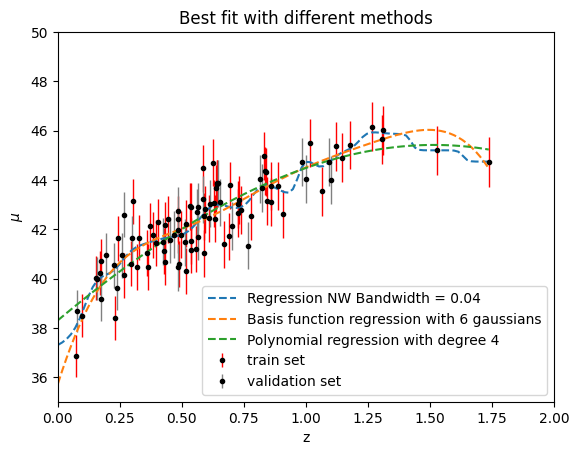

In [26]:
plt.errorbar(xtrain, ytrain, dytrain, fmt='.k', ecolor='red', lw=1,label='train set')
plt.errorbar(xvalid, yvalid, dyvalid, fmt='.k', ecolor='gray', lw=1,label='validation set')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

###Fit on training set only
#Basis function best fit
basis_mu = np.linspace(0, 2, n_gauss[idx_bf])[:, None]
sigma_basis = 1*(basis_mu[1]-basis_mu[0])
model = BasisFunctionRegression('gaussian', mu=basis_mu, sigma=sigma_basis)
model.fit(xtrain, ytrain, dytrain)
mu_pred_bf = model.predict(grid_test_bf)

#Kernel regression best fit
model = NadarayaWatson(kernel = 'gaussian', h = bw[idx_nw]) 
model.fit(xtrain, ytrain)
mu_pred_nw = model.predict(grid_test_nw)

#Polynomial regression best fit
model = PolynomialRegression(idx_pol) 
model.fit(xtrain, ytrain)
mu_pred_pol = model.predict(grid_test_pol)
plt.title("Best fit with different methods")
plt.plot(grid_test_nw, mu_pred_nw, linestyle = '--', label = f"Regression NW Bandwidth = {bw[idx_nw]:.2f}")
plt.plot(grid_test_bf, mu_pred_bf, linestyle = '--', label = f"Basis function regression with {n_gauss[idx_bf]} gaussians")
plt.plot(grid_test_pol, mu_pred_pol, linestyle = '--', label = f"Polynomial regression with degree {idx_pol+1}")
plt.legend()

The various models adapt adequatelly to unseen data. However, since the dataset is small, the accuracy of the prediction on unseen data can depend on which points of the dataset enters in the training set.